In [93]:
import numpy as np

# import data
train_1 = np.loadtxt('./train1.txt')
train_2 = np.loadtxt('./train2.txt')
test = np.loadtxt('./test.txt')

# get inputs and targets
train_1_in = train_1[0: len(train_1)-1]
train_1_out = train_1[1: len(train_1)]
train_2_in = train_2[0: len(train_2)-1]
train_2_out = train_2[1: len(train_2)]

# make input
train = np.concat((train_1_in, train_2_in), axis=0)
target = np.concat((train_1_out, train_2_out), axis=0)

In [94]:
# define psi transform
def psi_transform(x):
    transformed = np.zeros((x.shape[0], 10))
    if len(x.shape) == 1:
        
        transformed = np.zeros(10)

        transformed[0] = 1
        transformed[1] = x[0]
        transformed[2] = x[1]
        transformed[3] = x[0]**2
        transformed[4] = x[1]**2
        transformed[5] = x[0]*x[1]
        transformed[6] = x[0]**3
        transformed[7] = x[1]**3
        transformed[8] = x[1]*(x[0]**2)
        transformed[9] = (x[1]**2)*x[0]

    else:
        transformed = np.zeros((x.shape[0], 10))

        for i in range(x.shape[0]):
        
            transformed[i][0] = 1
            transformed[i][1] = x[i][0]
            transformed[i][2] = x[i][1]
            transformed[i][3] = x[i][0]**2
            transformed[i][4] = x[i][1]**2
            transformed[i][5] = x[i][0]*x[i][1]
            transformed[i][6] = x[i][0]**3
            transformed[i][7] = x[i][1]**3
            transformed[i][8] = x[i][1]*(x[i][0]**2)
            transformed[i][9] = (x[i][1]**2)*x[i][0]
            
    return transformed

In [95]:
# transform to observable of state space
psi_x = psi_transform(train)
psi_y = psi_transform(target)

In [97]:
# approximate koopman operator with least squares
psi_x_plus = np.linalg.inv(psi_x.T@psi_x)
psi_x_plus = psi_x_plus@psi_x.T
k = psi_x_plus@psi_y

In [99]:
# construct matrix to pick out the values of the state
c = np.zeros((10, 10))
c[0][1] = 1
c[1][2] = 1

In [102]:
# predict next state using x_next = C*K*Psi(x_current)
val = np.zeros((test.shape))
val[0, :] = test[0, :]
for i in range(1, test.shape[0]):
    temp = test[i-1, :]
    temp = psi_transform(temp)
    step = temp@k
    step = c@step
    val[i, 0] = step[0]
    val[i, 1] = step[1]

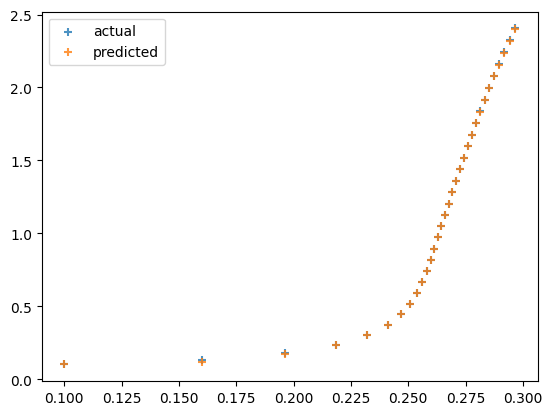

In [112]:
# plot
import matplotlib.pyplot as plt
x_targ, y_targ = zip(*test)
x_val, y_val = zip(*val)
plt.scatter(x_targ, y_targ, label= 'actual', marker='+', alpha = 0.8)
plt.scatter(x_val, y_val, label = 'predicted', marker='+', alpha = 0.8)
plt.legend()
plt.show()